# tsbench-forge — a guided walkthrough

`tsbench-forge` is a **continuous, hard-to-game benchmark for time-series
foundation models (TSFMs)**. Two halves work together:

1. **The forge (anti-gaming).** A self-improving loop that keeps the benchmark a
   moving target — closing memorization, pre-fitting, and saturation, with
   challenges derived deterministically from a commit-reveal seed so every
   validator agrees.
2. **The evaluation (the part that scores a model).** A probabilistic leaderboard
   (MASE / WQL / CRPS) that ranks a real TSFM against a reference panel, plus a
   *headroom* check that the benchmark can actually separate a better-than-classical
   model.

This notebook runs **numpy-only** — no API key, no network, no GPU. (With
`OPENROUTER_API_KEY` set, the forge proposer would call a real LLM; here it uses
the deterministic heuristic fallback.)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from config import WEAK_STATE, CONTEXT_LEN, HORIZON
from domains import default_live_source
from ingest import FreshBuffer
from forge_loop import run_forge, manifest_for
from generate import build_challenges
from seed import rng_for
from score import default_panel, panel_fitness, validate_panel, domain_coverage, stratified_fitness
from evaluate import leaderboard, probabilistic_panel, headroom, benchmark_has_headroom, ProbForecast
from sandbox import run_submission

BLOCK_HASH = "0xnotebook-demo"
EPOCHS = 18
print(f"context={CONTEXT_LEN}  horizon={HORIZON}  epochs={EPOCHS}")

context=256  horizon=48  epochs=18


## 1. A fresh, multi-domain live pool

The benchmark splices in *real* motifs that "didn't exist at commit time." Here a
seeded multi-domain zoo (random walk + Lorenz, Rössler, Hopf, Hénon, logistic,
OU, jump-diffusion) stands in for a real post-commit feed — broad enough to
certify a *foundation* model, not just one process.

In [2]:
buffer = FreshBuffer(default_live_source(), pool_size=96, motif_len=768)
buffer.refresh(np.random.default_rng(0xC0FFEE))
from collections import Counter
print("pool domains:", dict(Counter(buffer.pool_domains)))

pool domains: {'jump_diffusion': 7, 'random_walk': 24, 'mean_reverting': 11, 'lorenz': 14, 'henon': 6, 'rossler': 13, 'logistic': 16, 'limit_cycle': 5}


## 2. Run the forge — watch the benchmark improve itself

Starting from a deliberately **weak** (synthetic-heavy, easy-to-pre-fit) state,
the forge proposes one knob change per epoch and **keeps** it only if the
reference panel becomes more discriminating-and-valid. `fitness = spread ·
max(0, ordering) · gate` — three independent gates that must all hold at once.

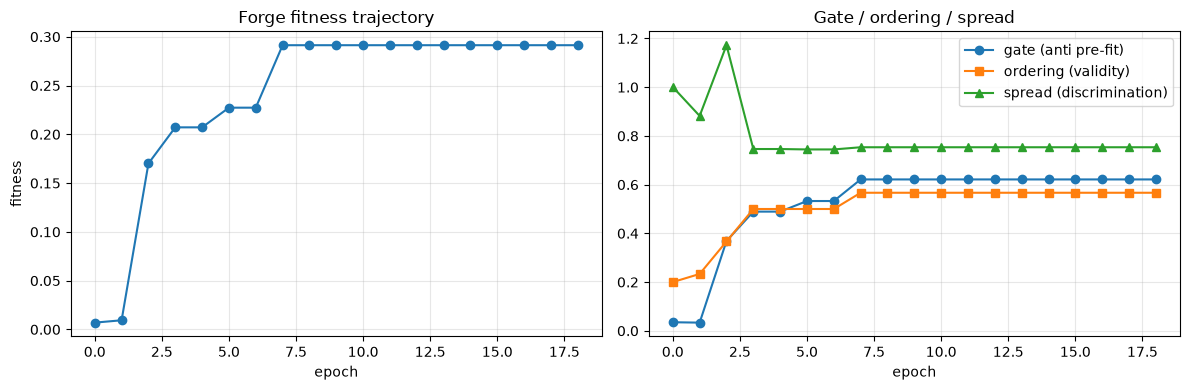

fitness 0.007 -> 0.291   (5 KEEPs)
final blend  synth=0.54  spliced=0.32  aug_live=0.14   (started 0.85 / 0.10 / 0.05)


In [3]:
final_state, log = run_forge(buffer, EPOCHS, BLOCK_HASH, WEAK_STATE)

epochs = [s.epoch for s in log]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, [s.fitness for s in log], marker="o")
ax[0].set(title="Forge fitness trajectory", xlabel="epoch", ylabel="fitness")
ax[0].grid(alpha=0.3)
ax[1].plot(epochs, [s.gate for s in log], marker="o", label="gate (anti pre-fit)")
ax[1].plot(epochs, [s.ordering for s in log], marker="s", label="ordering (validity)")
ax[1].plot(epochs, [s.spread for s in log], marker="^", label="spread (discrimination)")
ax[1].set(title="Gate / ordering / spread", xlabel="epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"fitness {log[0].fitness:.3f} -> {log[-1].fitness:.3f}   "
      f"({sum(1 for s in log if s.decision=='keep')} KEEPs)")
nf = final_state.normalized()
print(f"final blend  synth={nf.w_synth:.2f}  spliced={nf.w_spliced:.2f}  aug_live={nf.w_aug_live:.2f}"
      f"   (started 0.85 / 0.10 / 0.05)")

The forge rebalances **away from pre-fittable synthetic data**, which lifts the
generator-fitting `gate`. That's the benchmark hardening itself against the
easiest way to game it.

## 3. Commit-reveal: the challenges are a pure function of the seed

The forge commits a hashed manifest of the state it settled on; the concrete
challenges are derived from `seed = H(block_hash ‖ epoch ‖ manifest_hash)`,
revealed only after miners commit. Every validator replays identical challenges.

In [4]:
epoch = EPOCHS
mhash = manifest_for(final_state)
a = build_challenges(final_state, buffer, rng_for(BLOCK_HASH, epoch, mhash), 8)
b = build_challenges(final_state, buffer, rng_for(BLOCK_HASH, epoch, mhash), 8)
identical = all(np.array_equal(x.context, y.context) and np.array_equal(x.truth, y.truth)
                for x, y in zip(a, b))
print(f"manifest_hash = {mhash[:16]}...")
print(f"two independent replays are byte-identical: {identical}")

# The committed challenge set used for the rest of the notebook:
reveal = build_challenges(final_state, buffer, rng_for(BLOCK_HASH, epoch, mhash), 128)
print(f"revealed {len(reveal)} challenges")

manifest_hash = 0cb5007cf8fcad8a...
two independent replays are byte-identical: True
revealed 128 challenges


## 4. The reference panel & the validity gate

Validity comes from a *frozen reference panel*, not from trusting the data. A
challenge only counts if a panel of known-quality forecasters ranks in its known
order. The `strong` anchor must genuinely lead — `validate_panel` checks that
loudly, so a hollow anchor fails instead of silently making the gate meaningless.

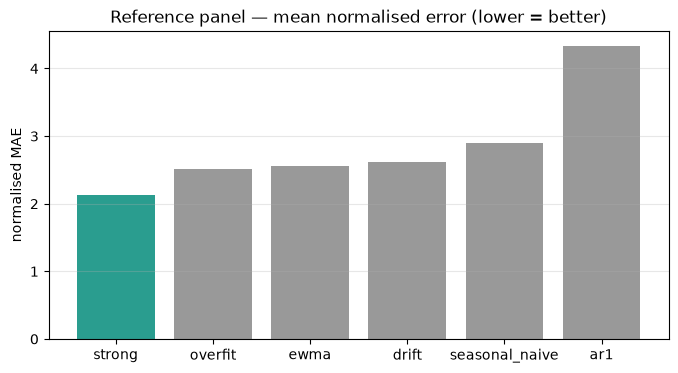

anchor validation: strong leads 'ewma' by 0.432  -> valid=True


In [5]:
panel = default_panel()
res = panel_fitness(reveal, panel)
errs = res["errors"]
order = sorted(errs, key=errs.get)

plt.figure(figsize=(8, 4))
plt.bar(order, [errs[m] for m in order], color=["#2a9d8f" if m=="strong" else "#999" for m in order])
plt.title("Reference panel — mean normalised error (lower = better)")
plt.ylabel("normalised MAE"); plt.grid(alpha=0.3, axis="y"); plt.show()

vp = validate_panel(reveal, panel)
print(f"anchor validation: strong leads '{vp['runner_up']}' by {vp['margin']:.3f}  -> valid={vp['valid']}")

## 5. Evaluating a model — the leaderboard (MASE / WQL / CRPS)

This is the half that **scores an actual TSFM**. A forecaster emits a
`ProbForecast` (mean + quantiles) and is judged on the metrics the TSFM
literature uses. Here we score the panel itself; to add a real model:

```python
from tsfm_adapters import load_tsfm      # pip install -e ".[chronos]"
models = {"chronos": load_tsfm("chronos"), **probabilistic_panel()}
leaderboard(models, reveal)
```

rank  model               MASE     WQL    CRPS
   1  strong             2.130   0.168   1.953
   2  ewma               2.561   0.188   2.183
   3  drift              2.617   0.181   2.098
   4  seasonal_naive     2.893   0.205   2.384
   5  ar1                4.338   0.310   3.606


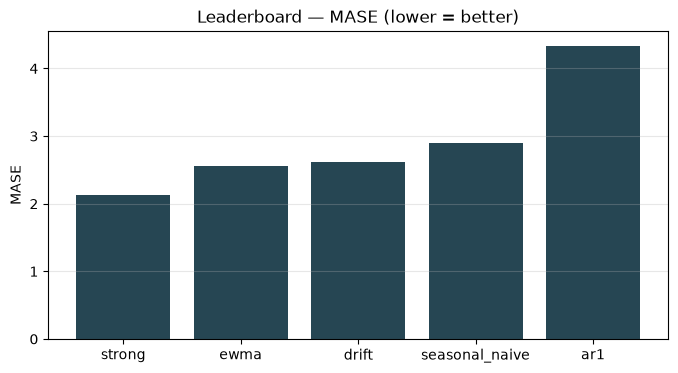

In [6]:
board = leaderboard(probabilistic_panel(), reveal)
print(f"{'rank':>4}  {'model':<16}{'MASE':>8}{'WQL':>8}{'CRPS':>8}")
for r in board:
    print(f"{r['rank']:>4}  {r['model']:<16}{r['mase']:>8.3f}{r['wql']:>8.3f}{r['crps']:>8.3f}")

names = [r["model"] for r in board]
plt.figure(figsize=(8, 4))
plt.bar(names, [r["mase"] for r in board], color="#264653")
plt.title("Leaderboard — MASE (lower = better)"); plt.ylabel("MASE")
plt.grid(alpha=0.3, axis="y"); plt.show()

## 6. Headroom — can the benchmark certify a *better* model?

A benchmark only certifies TSFMs if a genuinely better model scores measurably
better than the classical anchor. We inject a deliberately-superior probe (the
true future + small noise — better than any real model, but not perfect) and
confirm the benchmark rewards it. If this failed, no leaderboard here would be
trustworthy.

In [7]:
probe_rng = np.random.default_rng(7)
truth_by_id = {id(ch.context): np.asarray(ch.truth, dtype=float) for ch in reveal}

def superior_probe(context, meta=None):
    tgt = truth_by_id[id(context)]
    noisy = tgt + probe_rng.normal(0.0, 0.05 * (np.std(tgt) + 1e-8), size=tgt.shape)
    deciles = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
    return ProbForecast(mean=noisy, quantiles={q: noisy for q in deciles})

hr = headroom(superior_probe, reveal)
print(f"a superior model beats the anchor by {hr['mase_margin']:+.3f} MASE / "
      f"{hr['wql_margin']:+.3f} WQL")
print(f"benchmark_has_headroom = {benchmark_has_headroom(superior_probe, reveal)}")

a superior model beats the anchor by +2.054 MASE / +0.162 WQL


benchmark_has_headroom = True


## 7. A sample challenge and the anchor's forecast

What a single challenge actually looks like: an observed context, the hidden
truth over the horizon, and the `strong` anchor's prediction.

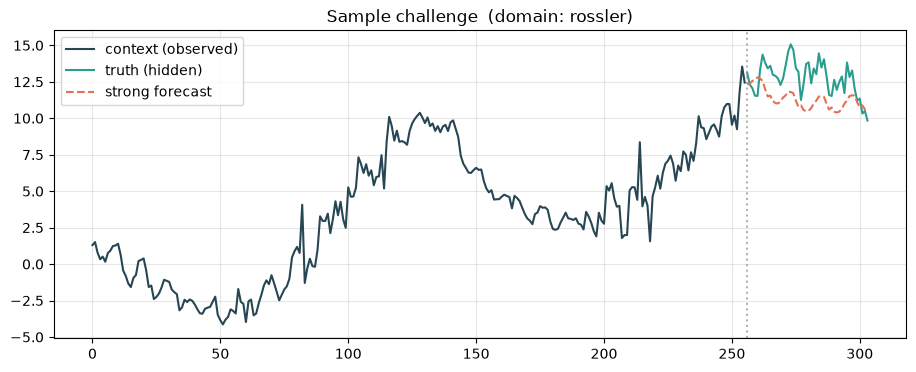

In [8]:
ch = reveal[0]
pred = panel["strong"](ch.context, getattr(ch, "meta", None))
n = len(ch.context)
plt.figure(figsize=(11, 4))
plt.plot(np.arange(n), ch.context, color="#264653", label="context (observed)")
plt.plot(np.arange(n, n+HORIZON), ch.truth, color="#2a9d8f", label="truth (hidden)")
plt.plot(np.arange(n, n+HORIZON), pred, "--", color="#e76f51", label="strong forecast")
plt.axvline(n, color="grey", ls=":", alpha=0.6)
plt.title(f"Sample challenge  (domain: {getattr(ch,'meta',{}).get('domain','?')})")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Submissions run in a sandbox, not just a linter

The static scan is a cheap pre-filter; the **real** boundary is isolated,
resource-limited execution. A clean forecaster runs; a hardcoded/cheating one is
rejected.

In [9]:
clean = (
    "import numpy as np\n"
    "def forecast(context):\n"
    "    level = np.mean(context[-12:])\n"
    "    slope = (context[-1] - context[0]) / len(context)\n"
    f"    return level + slope * np.arange(1, {HORIZON + 1})\n"
)
table = ", ".join(str(round(0.1*i, 2)) for i in range(40))
cheat = ("import numpy as np\nimport requests\n"
         f"ANSWERS = [{table}]\n"
         "def forecast(context):\n    return np.array(eval('ANSWERS'))\n")

for name, code_str in (("clean numpy forecaster", clean), ("hardcoded/cheating", cheat)):
    r = run_submission(code_str, reveal[0].context)
    detail = f"shape={r.prediction.shape}" if r.ok else (r.error or r.findings)
    print(f"{name:<24} -> status={r.status}  ({detail})")

clean numpy forecaster   -> status=ok  (shape=(48,))
hardcoded/cheating       -> status=rejected  (("line 2: network import 'requests'", 'line 3: embedded numeric array with 40 values (>= 20); looks like memorised data', "line 5: dynamic execution 'eval(...)'"))


## 9. Foundational breadth — good *across worlds*, not one process

A high score should mean "generalises across domains." Coverage is measured (the
effective number of data-generating processes), and fitness is reported per
domain so narrowness can't hide in an average.

In [10]:
cov = domain_coverage(reveal)
print(f"spans {cov['n_domains']} domains; effective (exp-entropy) = {cov['effective_domains']:.2f}")
print(f"\n{'domain':<16}{'n':>4}{'spread':>8}{'order':>8}{'gate':>7}")
for dom, m in sorted(stratified_fitness(reveal, panel).items(), key=lambda kv: -kv[1]['n']):
    print(f"{dom:<16}{m['n']:>4}{m['spread']:>8.2f}{m['ordering']:>+8.2f}{m['gate']:>7.2f}")

spans 8 domains; effective (exp-entropy) = 4.75

domain             n  spread   order   gate
synth             68    1.44   +0.33   0.00
random_walk       13    0.52   +0.87   0.97
mean_reverting    12    0.34   -0.20   0.07
lorenz            11    0.19   +0.60   0.19
logistic           9    0.59   +0.20   0.08
rossler            8    0.16   -0.20   0.16
jump_diffusion     4    0.35   +0.60   1.00
henon              3    0.20   -0.07   0.10


## Recap

- **Forge** → the benchmark hardens itself (gate ↑) and stays a moving target.
- **Commit-reveal** → identical, reproducible challenges for every validator.
- **Panel + `validate_panel`** → challenges only count when the anchor genuinely leads.
- **Leaderboard (MASE/WQL/CRPS) + `load_tsfm`** → scores an actual TSFM.
- **Headroom** → confirms the benchmark can certify a better-than-classical model.
- **Sandbox** → submissions are executed in isolation, not just linted.

Swap in a real anchor (`default_panel(strong_model=...)`), a real post-commit feed
(`feeds.py`), and a real model (`tsfm_adapters.load_tsfm`) for production.